# 08 — Calibração e Estabilidade Temporal

Este notebook complementa a avaliação multidimensional após a execução do OOT.

## Objetivos
- avaliar a calibração probabilística no Teste/Validação Operacional e no OOT;
- calcular Brier Score e Brier Skill Score;
- produzir curvas de calibração;
- medir estabilidade das variáveis por PSI;
- medir estabilidade dos scores por PSI;
- acompanhar mensalmente prevalência, ROC-AUC, PR-AUC e Brier Score.

## Regra metodológica
Nenhum modelo é retreinado ou ajustado. Threshold, Top-k, hiperparâmetros e pré-processamento permanecem congelados.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from IPython.display import display
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score, average_precision_score

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Diretórios e verificação do OOT

In [2]:
PROJECT_DIR = Path(r"C:\UnB\script_md")

PROCESSADOS_DIR = PROJECT_DIR / "Base de dados" / "processados"
MODELS_DIR = PROJECT_DIR / "outputs" / "modelos"
TABLES_DIR = PROJECT_DIR / "outputs" / "tabelas"
FIGURES_DIR = PROJECT_DIR / "outputs" / "figuras"
CONFIG_DIR = PROJECT_DIR / "outputs" / "config"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

INPUT_FILE = PROCESSADOS_DIR / "dataset_modelagem_preparado.csv"
CONFIG_FILE = CONFIG_DIR / "configuracao_operacional_congelada.json"
OOT_REGISTER_FILE = CONFIG_DIR / "registro_avaliacao_oot.json"

if not CONFIG_FILE.exists():
    raise FileNotFoundError("Configuração operacional congelada não encontrada.")

if not OOT_REGISTER_FILE.exists():
    raise FileNotFoundError(
        "Registro da avaliação OOT não encontrado. Execute primeiro o Script 07."
    )

with CONFIG_FILE.open("r", encoding="utf-8") as f:
    configuracao = json.load(f)

with OOT_REGISTER_FILE.open("r", encoding="utf-8") as f:
    registro_oot = json.load(f)

if registro_oot.get("avaliacao_final_executada") is not True:
    raise RuntimeError("A avaliação OOT ainda não está registrada como executada.")

print("Avaliação OOT confirmada.")
print(f"Estratégia operacional: {configuracao['estrategia_operacional']}")
print(f"Modelos: {configuracao['modelos_para_oot']}")

Avaliação OOT confirmada.
Estratégia operacional: threshold
Modelos: ['Regressão Logística', 'KNN', 'Random Forest', 'Gradient Boosting']


## 2. Carregamento da base e definição dos períodos

In [3]:
df = pd.read_csv(
    INPUT_FILE,
    sep=";",
    encoding="utf-8-sig",
    low_memory=False
)

TARGET = "target"

df_train = df[df["Amostra"] == "Treino"].sort_values("AAAA_MM").reset_index(drop=True)
df_teste = df[df["Amostra"] == "Teste"].sort_values("AAAA_MM").reset_index(drop=True)
df_oot = df[df["Amostra"] == "OOT"].sort_values("AAAA_MM").reset_index(drop=True)

print(f"Treino: {len(df_train):,} | {df_train['AAAA_MM'].min()} a {df_train['AAAA_MM'].max()}")
print(f"Teste:  {len(df_teste):,} | {df_teste['AAAA_MM'].min()} a {df_teste['AAAA_MM'].max()}")
print(f"OOT:    {len(df_oot):,} | {df_oot['AAAA_MM'].min()} a {df_oot['AAAA_MM'].max()}")

Treino: 12,032 | 2022_08 a 2024_07
Teste:  14,027 | 2024_08 a 2025_07
OOT:    32,072 | 2025_08 a 2026_07


## 3. Carregamento dos pipelines congelados

In [4]:
MAPA_ARQUIVOS = {
    "Regressão Logística": MODELS_DIR / "modelo_treino_regressao_logistica.joblib",
    "KNN": MODELS_DIR / "modelo_treino_knn.joblib",
    "Random Forest": MODELS_DIR / "modelo_treino_random_forest.joblib",
    "Gradient Boosting": MODELS_DIR / "modelo_treino_gradient_boosting.joblib"
}

nomes_modelos = configuracao["modelos_para_oot"]
modelos = {}

for nome in nomes_modelos:
    caminho = MAPA_ARQUIVOS.get(nome)

    if caminho is None:
        raise KeyError(f"Modelo não reconhecido: {nome}")

    if not caminho.exists():
        raise FileNotFoundError(f"Modelo não encontrado: {caminho}")

    modelos[nome] = joblib.load(caminho)

print("Pipelines carregados:")
for nome in modelos:
    print("-", nome)

Pipelines carregados:
- Regressão Logística
- KNN
- Random Forest
- Gradient Boosting


## 4. Identificação dos atributos por modelo

In [5]:
PREDITORES_PADRAO = [
    "Região",
    "UF",
    "Cidade",
    "Sexo",
    "Faixa Etária",
    "Área",
    "Assunto",
    "Grupo Problema",
    "Problema",
    "Como Comprou Contratou",
    "Procurou Empresa"
]

def obter_features_modelo(modelo):
    for step_name in ["codificacao", "preprocessamento"]:
        if step_name in modelo.named_steps:
            transformador = modelo.named_steps[step_name]
            if hasattr(transformador, "feature_names_in_"):
                return list(transformador.feature_names_in_)
    return PREDITORES_PADRAO.copy()

features_por_modelo = {
    nome: obter_features_modelo(modelo)
    for nome, modelo in modelos.items()
}

for nome, features in features_por_modelo.items():
    print(f"{nome}: {len(features)} atributos")
    print(features)
    print()

Regressão Logística: 11 atributos
['Região', 'UF', 'Cidade', 'Sexo', 'Faixa Etária', 'Área', 'Assunto', 'Grupo Problema', 'Problema', 'Como Comprou Contratou', 'Procurou Empresa']

KNN: 10 atributos
['Região', 'UF', 'Sexo', 'Faixa Etária', 'Área', 'Assunto', 'Grupo Problema', 'Problema', 'Como Comprou Contratou', 'Procurou Empresa']

Random Forest: 11 atributos
['Região', 'UF', 'Cidade', 'Sexo', 'Faixa Etária', 'Área', 'Assunto', 'Grupo Problema', 'Problema', 'Como Comprou Contratou', 'Procurou Empresa']

Gradient Boosting: 11 atributos
['Região', 'UF', 'Cidade', 'Sexo', 'Faixa Etária', 'Área', 'Assunto', 'Grupo Problema', 'Problema', 'Como Comprou Contratou', 'Procurou Empresa']



## 5. Probabilidades previstas nos três períodos

In [6]:
periodos = {
    "Treino": df_train,
    "Teste": df_teste,
    "OOT": df_oot
}

probabilidades = {nome: {} for nome in modelos}

for nome, modelo in modelos.items():
    features = features_por_modelo[nome]

    for periodo, dados in periodos.items():
        X = dados[features].copy()
        probabilidades[nome][periodo] = modelo.predict_proba(X)[:, 1]

print("Probabilidades calculadas.")

Probabilidades calculadas.


# PARTE A — Calibração

## 6. Brier Score

\[
BS=\frac{1}{N}\sum_{i=1}^{N}(p_i-y_i)^2
\]

Quanto menor, melhor.

Também será calculada uma referência \(BS_{ref}=\pi(1-\pi)\) e o Brier Skill Score:

\[
BSS=1-\frac{BS}{BS_{ref}}
\]

O BSS é usado apenas como medida complementar de desempenho relativo à prevalência observada em cada período.

In [7]:
linhas_brier = []

for nome in modelos:
    for periodo in ["Teste", "OOT"]:
        dados = periodos[periodo]
        y = dados[TARGET].astype(int).to_numpy()
        prob = probabilidades[nome][periodo]

        brier = brier_score_loss(y, prob)
        prevalencia = y.mean()
        brier_ref = prevalencia * (1 - prevalencia)
        bss = 1 - (brier / brier_ref) if brier_ref > 0 else np.nan

        linhas_brier.append({
            "Modelo": nome,
            "Período": periodo,
            "N": len(y),
            "Prevalência": prevalencia,
            "Brier Score": brier,
            "Brier Referência": brier_ref,
            "Brier Skill Score": bss
        })

resultado_brier = pd.DataFrame(linhas_brier)

display(resultado_brier.round(5))

resultado_brier.to_csv(
    TABLES_DIR / "calibracao_brier_teste_oot.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)

,Modelo,Período,N,Prevalência,Brier Score,Brier Referência,Brier Skill Score
0,Regressão Logística,Teste,14027,0.3846,0.2226,0.2367,0.0595
1,Regressão Logística,OOT,32072,0.2853,0.2093,0.2039,-0.0267
2,KNN,Teste,14027,0.3846,0.2294,0.2367,0.0309
3,KNN,OOT,32072,0.2853,0.2165,0.2039,-0.0617
4,Random Forest,Teste,14027,0.3846,0.2216,0.2367,0.0636
5,Random Forest,OOT,32072,0.2853,0.2094,0.2039,-0.0271
6,Gradient Boosting,Teste,14027,0.3846,0.2212,0.2367,0.0654
7,Gradient Boosting,OOT,32072,0.2853,0.2087,0.2039,-0.0234


## 7. Delta do Brier entre Teste e OOT

In [8]:
pivot_brier = resultado_brier.pivot(
    index="Modelo",
    columns="Período",
    values="Brier Score"
)

pivot_brier["Δ OOT-Teste"] = pivot_brier["OOT"] - pivot_brier["Teste"]

display(pivot_brier.round(5))

pivot_brier.to_csv(
    TABLES_DIR / "calibracao_brier_delta.csv",
    sep=";",
    encoding="utf-8-sig"
)

Período,OOT,Teste,Δ OOT-Teste
Modelo,,,
Gradient Boosting,0.2087,0.2212,-0.0126
KNN,0.2165,0.2294,-0.0129
Random Forest,0.2094,0.2216,-0.0122
Regressão Logística,0.2093,0.2226,-0.0133


## 8. Curvas de calibração

São utilizados 10 grupos quantílicos. A diagonal representa calibração perfeita.

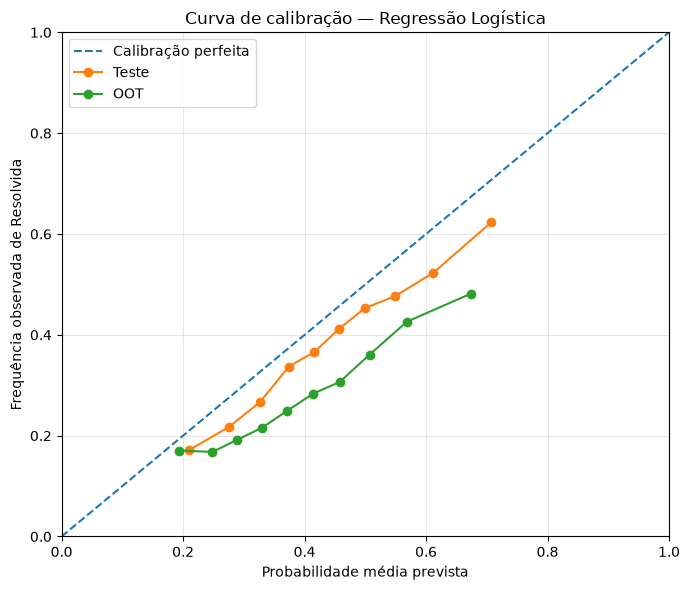

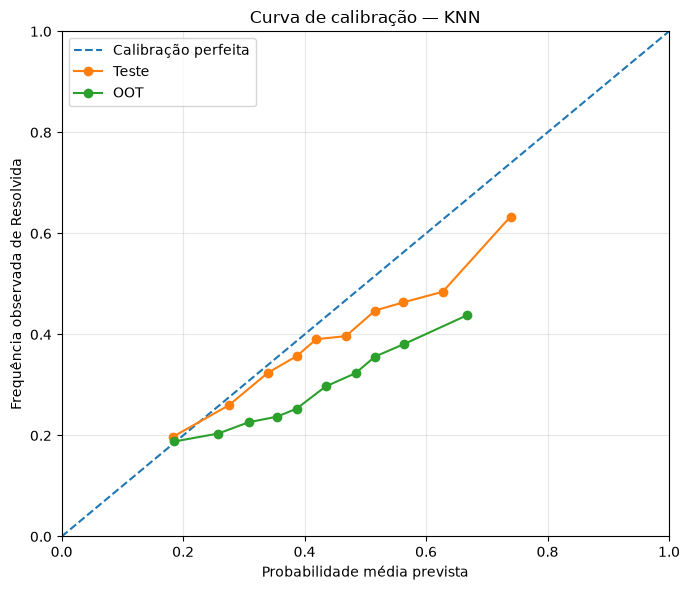

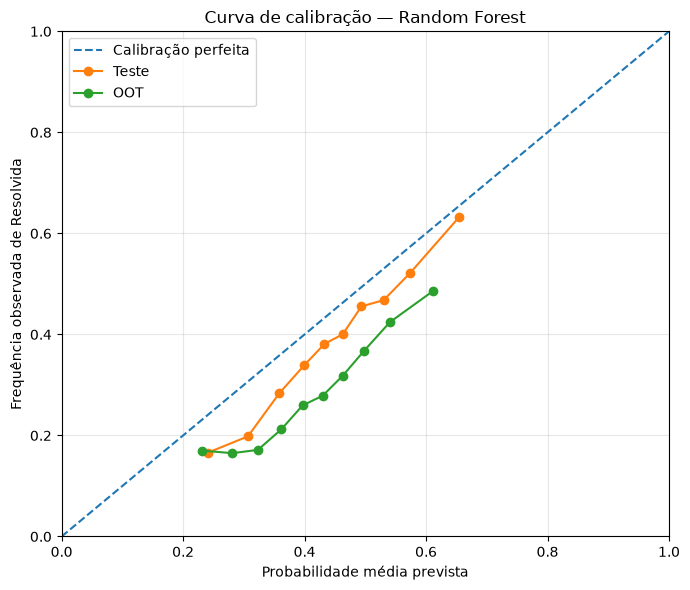

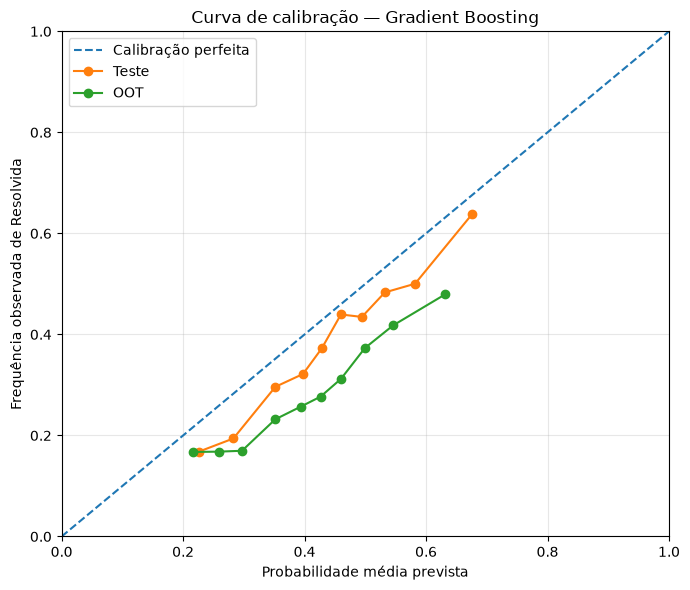

In [9]:
linhas_calibracao = []

for nome in modelos:
    fig, ax = plt.subplots(figsize=(7, 6))

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Calibração perfeita"
    )

    for periodo in ["Teste", "OOT"]:
        dados = periodos[periodo]
        y = dados[TARGET].astype(int).to_numpy()
        prob = probabilidades[nome][periodo]

        frac_pos, mean_pred = calibration_curve(
            y,
            prob,
            n_bins=10,
            strategy="quantile"
        )

        ax.plot(
            mean_pred,
            frac_pos,
            marker="o",
            label=periodo
        )

        for bin_id, (prevista, observada) in enumerate(
            zip(mean_pred, frac_pos),
            start=1
        ):
            linhas_calibracao.append({
                "Modelo": nome,
                "Período": periodo,
                "Bin": bin_id,
                "Probabilidade média prevista": prevista,
                "Frequência observada": observada
            })

    ax.set_title(f"Curva de calibração — {nome}")
    ax.set_xlabel("Probabilidade média prevista")
    ax.set_ylabel("Frequência observada de Resolvida")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(alpha=0.3)

    plt.tight_layout()

    slug = (
        nome.lower()
        .replace(" ", "_")
        .replace("ã", "a")
        .replace("ç", "c")
        .replace("ó", "o")
        .replace("í", "i")
        .replace("é", "e")
    )

    plt.savefig(
        FIGURES_DIR / f"calibracao_{slug}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

tabela_calibracao = pd.DataFrame(linhas_calibracao)

tabela_calibracao.to_csv(
    TABLES_DIR / "calibracao_curvas_bins.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)

# PARTE B — Estabilidade das Variáveis

## 9. Population Stability Index (PSI)

O PSI é calculado em:

- Treino × Teste;
- Treino × OOT.

Será tratado como medida contínua de deslocamento populacional, sem classificação automática por faixas universais.

In [10]:
def psi_categorico(referencia, comparacao, epsilon=1e-6):
    ref = (
        referencia.fillna("__MISSING__")
        .astype(str)
        .value_counts(normalize=True)
    )

    comp = (
        comparacao.fillna("__MISSING__")
        .astype(str)
        .value_counts(normalize=True)
    )

    categorias = ref.index.union(comp.index)

    p = ref.reindex(categorias, fill_value=0).astype(float)
    q = comp.reindex(categorias, fill_value=0).astype(float)

    p = p.clip(lower=epsilon)
    q = q.clip(lower=epsilon)

    p = p / p.sum()
    q = q / q.sum()

    componentes = (q - p) * np.log(q / p)

    detalhe = pd.DataFrame({
        "Categoria": categorias,
        "Referência": p.values,
        "Comparação": q.values,
        "Componente PSI": componentes.values
    })

    return float(componentes.sum()), detalhe

In [11]:
linhas_psi = []
detalhes_psi = {}

for variavel in PREDITORES_PADRAO:
    for nome_comp, dados_comp in [
        ("Treino → Teste", df_teste),
        ("Treino → OOT", df_oot)
    ]:
        psi, detalhe = psi_categorico(
            df_train[variavel],
            dados_comp[variavel]
        )

        linhas_psi.append({
            "Variável": variavel,
            "Comparação": nome_comp,
            "PSI": psi,
            "Categorias Treino": df_train[variavel].nunique(),
            "Categorias Comparação": dados_comp[variavel].nunique()
        })

        detalhes_psi[(variavel, nome_comp)] = detalhe

resultado_psi_variaveis = pd.DataFrame(linhas_psi).sort_values(
    ["Comparação", "PSI"],
    ascending=[True, False]
).reset_index(drop=True)

display(resultado_psi_variaveis.round(6))

resultado_psi_variaveis.to_csv(
    TABLES_DIR / "estabilidade_psi_variaveis.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)

,Variável,Comparação,PSI,Categorias Treino,Categorias Comparação
0,Cidade,Treino → OOT,0.9020,1774,2978
1,Problema,Treino → OOT,0.5683,85,83
2,Assunto,Treino → OOT,0.4828,27,26
3,Grupo Problema,Treino → OOT,0.1819,8,8
4,Como Comprou Contratou,Treino → OOT,0.0772,9,9
5,UF,Treino → OOT,0.0264,27,27
6,Sexo,Treino → OOT,0.0173,3,3
7,Faixa Etária,Treino → OOT,0.0108,7,7
8,Procurou Empresa,Treino → OOT,0.0085,2,2
9,Área,Treino → OOT,0.0084,3,3


## 10. Gráficos do PSI das variáveis

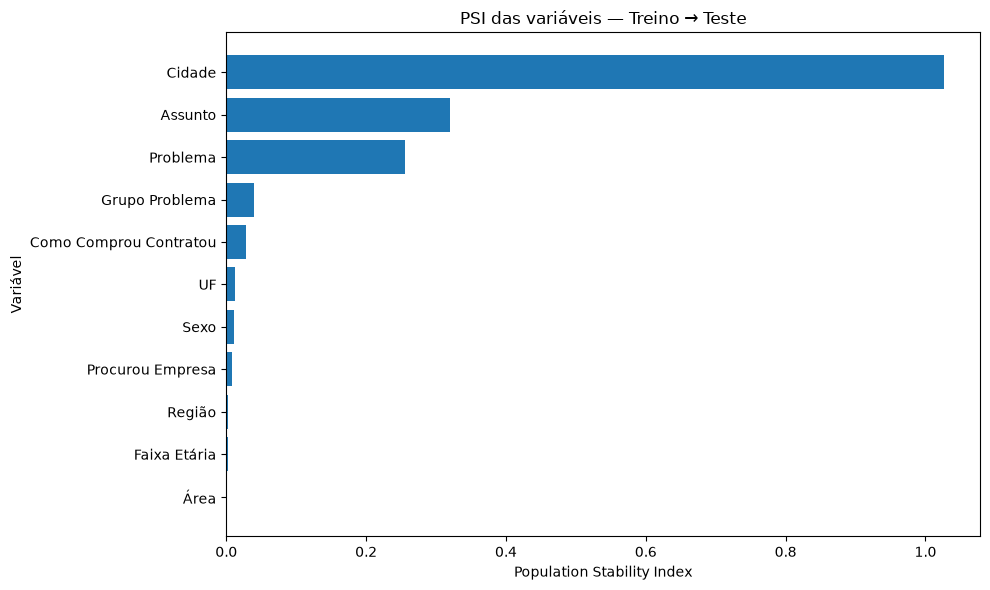

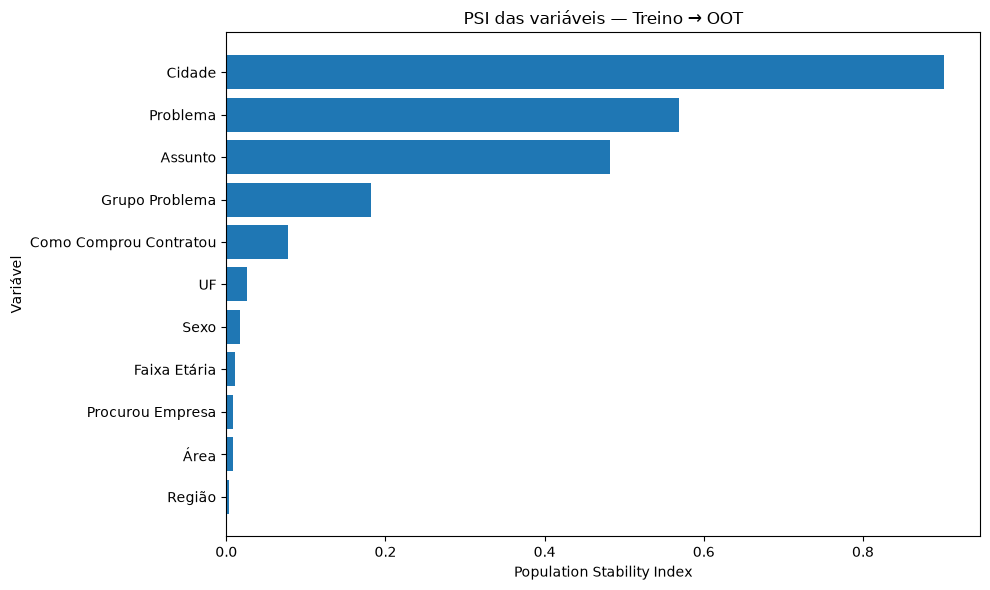

In [13]:
for comparacao in ["Treino → Teste", "Treino → OOT"]:
    dados_plot = (
        resultado_psi_variaveis[
            resultado_psi_variaveis["Comparação"] == comparacao
        ]
        .sort_values("PSI")
    )

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.barh(
        dados_plot["Variável"],
        dados_plot["PSI"]
    )

    ax.set_title(f"PSI das variáveis — {comparacao}")
    ax.set_xlabel("Population Stability Index")
    ax.set_ylabel("Variável")

    plt.tight_layout()

    sufixo = "treino_teste" if comparacao == "Treino → Teste" else "treino_oot"

    plt.savefig(
        FIGURES_DIR / f"estabilidade_psi_{sufixo}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

## 11. Categorias que mais contribuíram para o PSI no OOT

In [14]:
top_variaveis_oot = (
    resultado_psi_variaveis[
        resultado_psi_variaveis["Comparação"] == "Treino → OOT"
    ]
    .nlargest(3, "PSI")["Variável"]
    .tolist()
)

for variavel in top_variaveis_oot:
    print()
    print("=" * 80)
    print(f"Variável: {variavel}")
    print("=" * 80)

    detalhe = detalhes_psi[(variavel, "Treino → OOT")].copy()
    detalhe["Contribuição Absoluta"] = detalhe["Componente PSI"].abs()

    detalhe = detalhe.sort_values(
        "Contribuição Absoluta",
        ascending=False
    ).head(15)

    detalhe["Treino (%)"] = detalhe["Referência"] * 100
    detalhe["OOT (%)"] = detalhe["Comparação"] * 100

    display(
        detalhe[
            ["Categoria", "Treino (%)", "OOT (%)", "Componente PSI"]
        ].round(6)
    )


Variável: Cidade


,Categoria,Treino (%),OOT (%),Componente PSI
408,Boqueirão do Piauí,0.2158,0.0062,0.0074
425,Brasília,5.4521,3.6531,0.0072
1843,Mineiros,0.0001,0.0779,0.0052
3287,Água Branca,0.1577,0.0062,0.0049
119,Angicos,0.0001,0.0717,0.0047
1575,Juazeiro do Piauí,0.0581,0.0001,0.0037
2589,Salvador,3.4522,2.4312,0.0036
3102,Trairão,0.0001,0.0499,0.0031
2531,Rio de Janeiro,4.1990,3.1419,0.0031
544,Camocim,0.0001,0.0468,0.0029



Variável: Problema


,Categoria,Treino (%),OOT (%),Componente PSI
22,"Cálculo de juros, saldo devedor (contestação, solicitação de histórico, dúvidas)",5.4022,20.1763,0.1947
85,SAC - Dificuldadede de contato / acesso,1.0638,0.0001,0.0986
78,Renegociação / parcelamento de dívida,12.6745,22.4867,0.0563
13,"Cobrança de tarifas, taxas, valores não previstos / não informados",7.5881,3.7665,0.0268
84,SAC - Dificuldade para cancelar o serviço,4.3384,1.7710,0.0230
9,"Clonagem, fraude, furto e roubo",3.4574,1.3158,0.0207
32,"Dificuldade de contato ou acesso aos serviços - caixa eletrônico, agência, internet banking",1.2217,0.2744,0.0141
18,Cobrança por serviço/produto não contratado / não reconhecido / não solicitado,4.6792,2.4881,0.0138
33,"Dificuldade de pagamento, saque, depósito, transferência",0.7812,0.1996,0.0079
20,"Coleta, uso ou compartilhamento indevido ou não autorizado de dados pessoais ou financeiros",1.3880,0.5456,0.0079



Variável: Assunto


,Categoria,Treino (%),OOT (%),Componente PSI
1,Cartão de Crédito / Cartão de Débito / Cartão de Loja,11.8517,30.0542,0.1694
5,Conta corrente / Salário / Poupança /Conta Aposentadoria,27.7178,10.9005,0.1570
0,Atendimento Bancário,14.9767,6.8034,0.0645
8,Crédito Pessoal e Demais Empréstimos (exceto financiamento de imóveis e veículos),23.0635,32.7856,0.0342
25,Serviço de pagamento online/ via celular/ maquininha,2.0445,0.7639,0.0126
6,Crédito Consignado (para servidores públicos ou trabalhadores do setor privado),7.1892,9.9370,0.0089
13,Investimentos / Aplicações / Câmbio / Previdência Privada,1.2217,0.4771,0.0070
15,"Programas de Fidelidade / Benefícios (pontos, milhagem etc)",2.2689,1.2410,0.0062
11,Financiamento de Imóveis,1.5376,0.7951,0.0049
10,Demais Seguros,0.8644,0.3679,0.0042


# PARTE C — Estabilidade dos Scores

## 12. PSI das probabilidades previstas

Os intervalos dos scores são definidos pelos quantis do Treino e mantidos fixos para Teste e OOT.

In [15]:
def criar_bins_score(score_referencia, n_bins=10):
    cortes = np.quantile(
        score_referencia,
        np.linspace(0, 1, n_bins + 1)
    )

    cortes = np.unique(cortes)

    if len(cortes) < 3:
        cortes = np.linspace(0, 1, n_bins + 1)

    cortes[0] = -np.inf
    cortes[-1] = np.inf

    return cortes


def psi_numerico_bins_fixos(referencia, comparacao, cortes, epsilon=1e-6):
    ref_bins = pd.cut(referencia, bins=cortes, include_lowest=True)
    comp_bins = pd.cut(comparacao, bins=cortes, include_lowest=True)

    categorias = ref_bins.categories

    p = (
        pd.Series(ref_bins)
        .value_counts(normalize=True, sort=False)
        .reindex(categorias, fill_value=0)
        .astype(float)
    )

    q = (
        pd.Series(comp_bins)
        .value_counts(normalize=True, sort=False)
        .reindex(categorias, fill_value=0)
        .astype(float)
    )

    p = p.clip(lower=epsilon)
    q = q.clip(lower=epsilon)

    p = p / p.sum()
    q = q / q.sum()

    componentes = (q - p) * np.log(q / p)

    return float(componentes.sum())

In [16]:
linhas_psi_scores = []

for nome in modelos:
    score_train = probabilidades[nome]["Treino"]
    cortes = criar_bins_score(score_train, n_bins=10)

    for comparacao, periodo in [
        ("Treino → Teste", "Teste"),
        ("Treino → OOT", "OOT")
    ]:
        psi_score = psi_numerico_bins_fixos(
            score_train,
            probabilidades[nome][periodo],
            cortes
        )

        linhas_psi_scores.append({
            "Modelo": nome,
            "Comparação": comparacao,
            "PSI Score": psi_score
        })

resultado_psi_scores = pd.DataFrame(linhas_psi_scores)

display(resultado_psi_scores.round(6))

resultado_psi_scores.to_csv(
    TABLES_DIR / "estabilidade_psi_scores.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)

,Modelo,Comparação,PSI Score
0,Regressão Logística,Treino → Teste,0.0161
1,Regressão Logística,Treino → OOT,0.1386
2,KNN,Treino → Teste,0.0071
3,KNN,Treino → OOT,0.0887
4,Random Forest,Treino → Teste,0.0152
5,Random Forest,Treino → OOT,0.1502
6,Gradient Boosting,Treino → Teste,0.0225
7,Gradient Boosting,Treino → OOT,0.1648


# PARTE D — Estabilidade Mensal

## 13. Métricas mensais no Teste e no OOT

São calculadas mensalmente:
- prevalência;
- ROC-AUC;
- PR-AUC;
- Brier Score.

Os meses do Treino não entram nesta análise de desempenho porque seriam previsões in-sample.

In [17]:
df_avaliacao = pd.concat(
    [
        df_teste.assign(Periodo_Avaliacao="Teste"),
        df_oot.assign(Periodo_Avaliacao="OOT")
    ],
    ignore_index=True
)

linhas_mensais = []

for nome, modelo in modelos.items():
    features = features_por_modelo[nome]

    for mes, grupo in df_avaliacao.groupby("AAAA_MM", sort=True):
        y_mes = grupo[TARGET].astype(int).to_numpy()
        prob_mes = modelo.predict_proba(grupo[features])[:, 1]

        if len(np.unique(y_mes)) == 2:
            roc_auc = roc_auc_score(y_mes, prob_mes)
            pr_auc = average_precision_score(y_mes, prob_mes)
        else:
            roc_auc = np.nan
            pr_auc = np.nan

        linhas_mensais.append({
            "AAAA_MM": mes,
            "Período": grupo["Periodo_Avaliacao"].iloc[0],
            "Modelo": nome,
            "N": len(grupo),
            "Prevalência": y_mes.mean(),
            "ROC-AUC": roc_auc,
            "PR-AUC": pr_auc,
            "Brier Score": brier_score_loss(y_mes, prob_mes)
        })

metricas_mensais = pd.DataFrame(linhas_mensais).sort_values(
    ["AAAA_MM", "Modelo"]
).reset_index(drop=True)

display(metricas_mensais.head(20).round(5))

metricas_mensais.to_csv(
    TABLES_DIR / "estabilidade_metricas_mensais.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)

,AAAA_MM,Período,Modelo,N,Prevalência,ROC-AUC,PR-AUC,Brier Score
0,2024_08,Teste,Gradient Boosting,627,0.4801,0.6523,0.6274,0.2306
1,2024_08,Teste,KNN,627,0.4801,0.6271,0.5836,0.2395
2,2024_08,Teste,Random Forest,627,0.4801,0.6508,0.6182,0.2320
3,2024_08,Teste,Regressão Logística,627,0.4801,0.6445,0.6256,0.2326
4,2024_09,Teste,Gradient Boosting,562,0.5160,0.6281,0.6374,0.2373
5,2024_09,Teste,KNN,562,0.5160,0.6266,0.6343,0.2396
6,2024_09,Teste,Random Forest,562,0.5160,0.6303,0.6461,0.2362
7,2024_09,Teste,Regressão Logística,562,0.5160,0.6116,0.6245,0.2434
8,2024_10,Teste,Gradient Boosting,867,0.4683,0.6546,0.6112,0.2304
9,2024_10,Teste,KNN,867,0.4683,0.6284,0.5996,0.2359


## 14. Evolução mensal da ROC-AUC

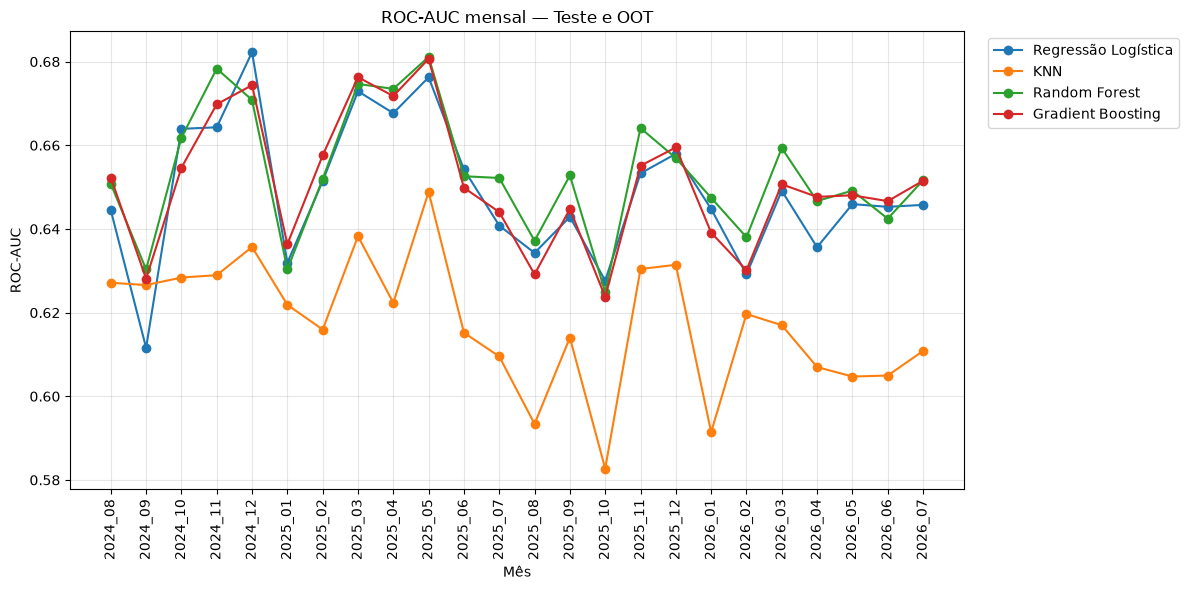

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))

for nome in nomes_modelos:
    dados_plot = metricas_mensais[metricas_mensais["Modelo"] == nome]

    ax.plot(
        dados_plot["AAAA_MM"],
        dados_plot["ROC-AUC"],
        marker="o",
        label=nome
    )

ax.set_title("ROC-AUC mensal — Teste e OOT")
ax.set_xlabel("Mês")
ax.set_ylabel("ROC-AUC")
ax.tick_params(axis="x", rotation=90)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "estabilidade_roc_auc_mensal.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 15. Evolução mensal da PR-AUC

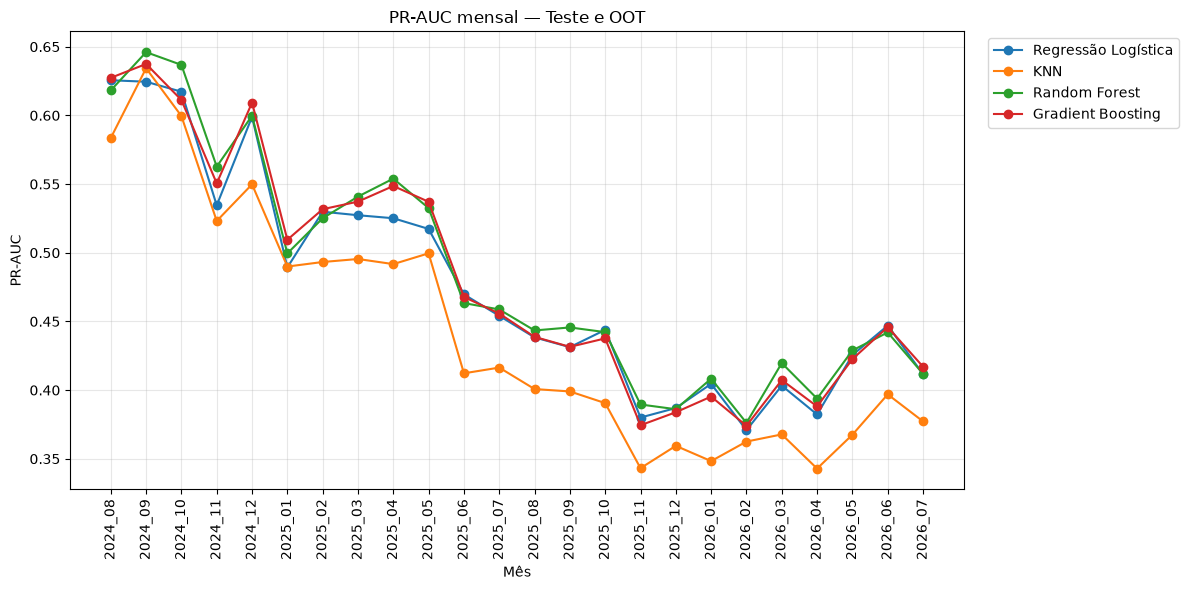

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))

for nome in nomes_modelos:
    dados_plot = metricas_mensais[metricas_mensais["Modelo"] == nome]

    ax.plot(
        dados_plot["AAAA_MM"],
        dados_plot["PR-AUC"],
        marker="o",
        label=nome
    )

ax.set_title("PR-AUC mensal — Teste e OOT")
ax.set_xlabel("Mês")
ax.set_ylabel("PR-AUC")
ax.tick_params(axis="x", rotation=90)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "estabilidade_pr_auc_mensal.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 16. Evolução mensal do Brier Score

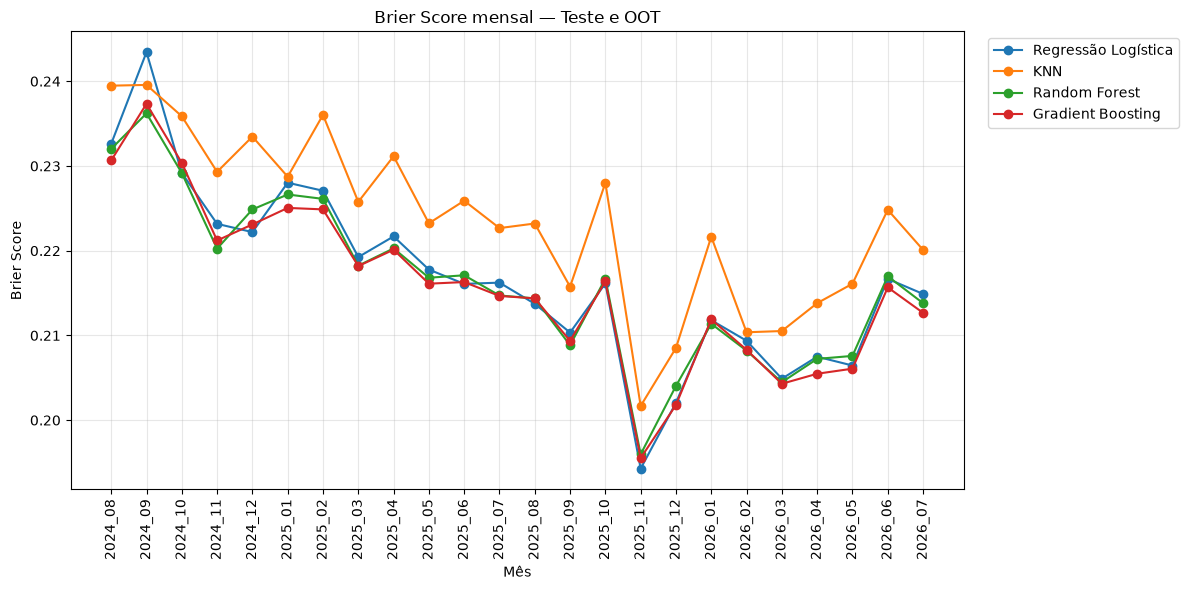

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))

for nome in nomes_modelos:
    dados_plot = metricas_mensais[metricas_mensais["Modelo"] == nome]

    ax.plot(
        dados_plot["AAAA_MM"],
        dados_plot["Brier Score"],
        marker="o",
        label=nome
    )

ax.set_title("Brier Score mensal — Teste e OOT")
ax.set_xlabel("Mês")
ax.set_ylabel("Brier Score")
ax.tick_params(axis="x", rotation=90)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "estabilidade_brier_mensal.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 17. Evolução mensal da prevalência

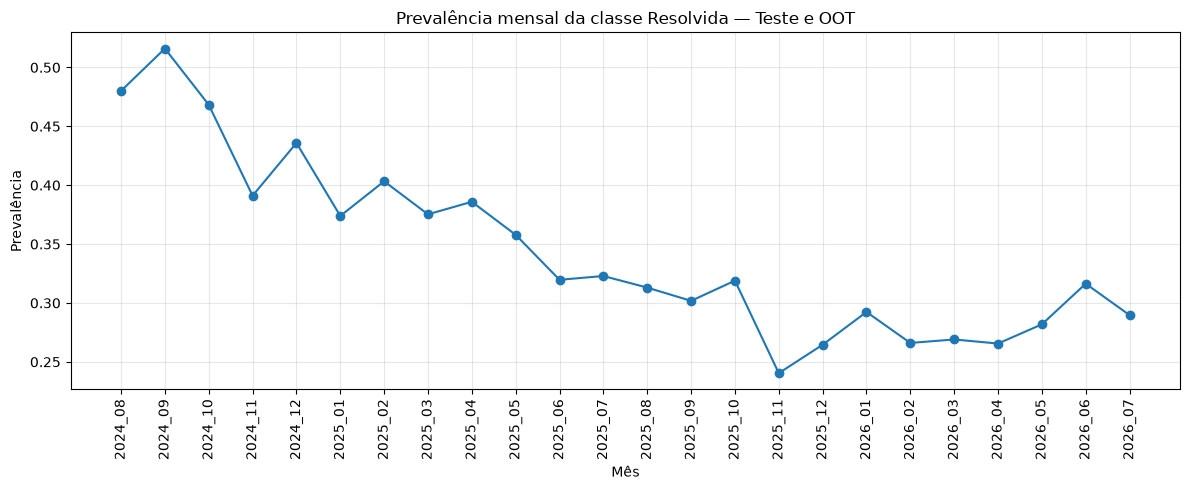

In [21]:
prevalencia_mensal = (
    df_avaliacao
    .groupby(["AAAA_MM", "Periodo_Avaliacao"])[TARGET]
    .agg(N="size", Prevalência="mean")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    prevalencia_mensal["AAAA_MM"],
    prevalencia_mensal["Prevalência"],
    marker="o"
)

ax.set_title("Prevalência mensal da classe Resolvida — Teste e OOT")
ax.set_xlabel("Mês")
ax.set_ylabel("Prevalência")
ax.tick_params(axis="x", rotation=90)
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "estabilidade_prevalencia_mensal.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

prevalencia_mensal.to_csv(
    TABLES_DIR / "estabilidade_prevalencia_mensal.csv",
    sep=";",
    encoding="utf-8-sig",
    index=False
)

# PARTE E — Síntese

In [22]:
print("=" * 80)
print("CALIBRAÇÃO")
print("=" * 80)

for nome in nomes_modelos:
    temp = resultado_brier[
        resultado_brier["Modelo"] == nome
    ].set_index("Período")

    print(
        f"{nome}: "
        f"Brier {temp.loc['Teste', 'Brier Score']:.4f} → "
        f"{temp.loc['OOT', 'Brier Score']:.4f}; "
        f"BSS {temp.loc['Teste', 'Brier Skill Score']:.4f} → "
        f"{temp.loc['OOT', 'Brier Skill Score']:.4f}."
    )

print()
print("=" * 80)
print("MAIORES PSI DAS VARIÁVEIS — TREINO → OOT")
print("=" * 80)

psi_oot = (
    resultado_psi_variaveis[
        resultado_psi_variaveis["Comparação"] == "Treino → OOT"
    ]
    .sort_values("PSI", ascending=False)
)

for _, linha in psi_oot.head(5).iterrows():
    print(
        f"{linha['Variável']}: PSI = {linha['PSI']:.4f}"
    )

print()
print("=" * 80)
print("ESTABILIDADE DOS SCORES")
print("=" * 80)

for _, linha in resultado_psi_scores.iterrows():
    print(
        f"{linha['Modelo']} | {linha['Comparação']}: "
        f"PSI Score = {linha['PSI Score']:.4f}"
    )

print()
print(
    "A conclusão deve integrar discriminação, classificação, "
    "calibração, estabilidade temporal e interpretabilidade, "
    "sem selecionar um modelo com base em uma única métrica."
)

CALIBRAÇÃO
Regressão Logística: Brier 0.2226 → 0.2093; BSS 0.0595 → -0.0267.
KNN: Brier 0.2294 → 0.2165; BSS 0.0309 → -0.0617.
Random Forest: Brier 0.2216 → 0.2094; BSS 0.0636 → -0.0271.
Gradient Boosting: Brier 0.2212 → 0.2087; BSS 0.0654 → -0.0234.

MAIORES PSI DAS VARIÁVEIS — TREINO → OOT
Cidade: PSI = 0.9020
Problema: PSI = 0.5683
Assunto: PSI = 0.4828
Grupo Problema: PSI = 0.1819
Como Comprou Contratou: PSI = 0.0772

ESTABILIDADE DOS SCORES
Regressão Logística | Treino → Teste: PSI Score = 0.0161
Regressão Logística | Treino → OOT: PSI Score = 0.1386
KNN | Treino → Teste: PSI Score = 0.0071
KNN | Treino → OOT: PSI Score = 0.0887
Random Forest | Treino → Teste: PSI Score = 0.0152
Random Forest | Treino → OOT: PSI Score = 0.1502
Gradient Boosting | Treino → Teste: PSI Score = 0.0225
Gradient Boosting | Treino → OOT: PSI Score = 0.1648

A conclusão deve integrar discriminação, classificação, calibração, estabilidade temporal e interpretabilidade, sem selecionar um modelo com base em 

## 18. Arquivos produzidos

### Tabelas
- `calibracao_brier_teste_oot.csv`
- `calibracao_brier_delta.csv`
- `calibracao_curvas_bins.csv`
- `estabilidade_psi_variaveis.csv`
- `estabilidade_psi_scores.csv`
- `estabilidade_metricas_mensais.csv`
- `estabilidade_prevalencia_mensal.csv`

### Próxima etapa
**09 — Interpretabilidade dos modelos**, seguida da síntese multidimensional final.